## Questão 1

Considere o sinal de tempo contínuo definido pela expressão:

$$
x(t)=\left(t^2-1\right)\left[u(t-1)-u(t-2)\right]
$$
---

a) Plote o sinal $x(t)$ para:

$$
0 \leq t \leq 3
$$

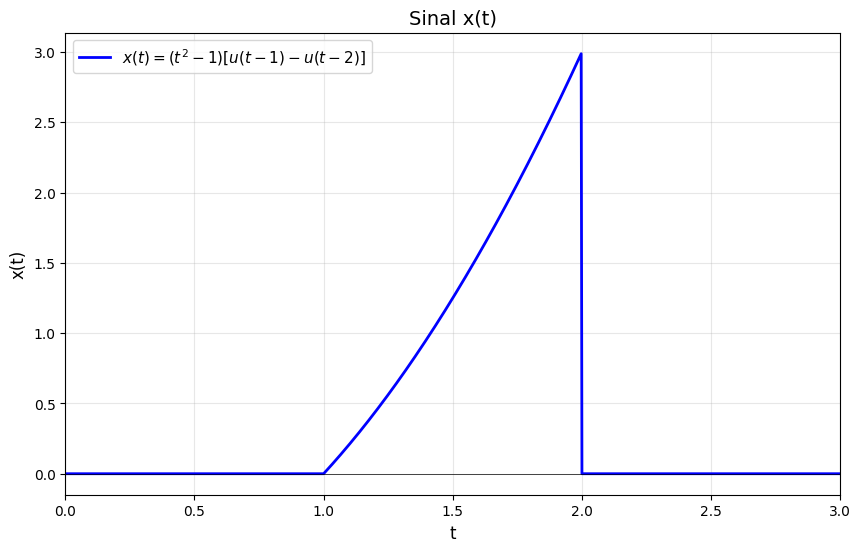

In [13]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 3, 1000)

def u(t_val):
    return np.where(t_val >= 0, 1, 0)

x = (t**2 - 1) * (u(t - 1) - u(t - 2))

plt.figure(figsize=(10, 6))
plt.plot(t, x, 'b-', linewidth=2, label=r'$x(t) = (t^2 - 1)[u(t-1) - u(t-2)]$')
plt.grid(True, alpha=0.3)
plt.xlabel('t', fontsize=12)
plt.ylabel('x(t)', fontsize=12)
plt.title('Sinal x(t)', fontsize=14)
plt.legend(fontsize=11)
plt.xlim(0, 3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

b) Calcule, de forma analítica, a energia do sinal $x(t)$.


O sinal é definido por:

$$
x(t) = (t^2-1)\,[u(t-1)-u(t-2)]
$$

A energia do sinal é dada por:

$$
E_x = \int_{-\infty}^{\infty} |x(t)|^2 \, dt
$$

Como o sinal existe apenas no intervalo $0 \leq t \leq 2$, temos:

$$
E_x = \int_{1}^{2} (t^2-1)^2 \, dt
$$

Expandindo:

$$
(t^2-1)^2 = t^4 - 2t^2 + 1
$$

Logo,

$$
E_x = \int_{1}^{2} (t^4 - 2t^2 + 1)\,dt
$$

Separando as integrais:

$$
E_x =
\int_{1}^{2} t^4\,dt
-2\int_{1}^{2} t^2\,dt
+\int_{1}^{2} 1\,dt
$$

Calculando a primeira integral, temos: 

$$
\int_{1}^{2} t^4\,dt
=
\left[\frac{t^5}{5}\right]_{1}^{2}
=
\frac{2^5}{5} - \frac{1^5}{5}
=
\frac{32}{5} - \frac{1}{5}
=
\frac{31}{5}
$$

Calculando a segunda integral, temos: 

$$
-2\int_{1}^{2} t^2\,dt
=
-2\left[\frac{t^3}{3}\right]_{1}^{2}
=
-2\left(\frac{2^3}{3} - \frac{1^3}{3}\right)
=
-2\left(\frac{8}{3} - \frac{1}{3}\right)
=
-2\left(\frac{7}{3}\right)
=
-\frac{14}{3}
$$

Já a terceira:

$$
\int_{1}^{2} 1\,dt
=
[t]_{1}^{2}
=
2-1
=
1
$$

Somando os resultados:

$$
E_x
=
\frac{31}{5}
-\frac{14}{3}
+1
$$

$$
E_x
=
\frac{93}{15}
-\frac{70}{15}
+\frac{15}{15}
$$

$$
E_x
=
\frac{38}{15}
$$

$$
\boxed{E_x = \frac{38}{15}}
$$

In [14]:
from fractions import Fraction

# Energia analítica
E_exact = Fraction(38, 15)

print(f"Energia (analítica) = {E_exact} ≈ {float(E_exact):.6f}")

Energia (analítica) = 38/15 ≈ 2.533333


c) Determine, de forma numérica, a energia do sinal $x(t)$. Compare com o resultado do item anterior.

A energia do sinal foi calculada de duas maneiras: analítica e computacional.

Na forma analítica, utilizou-se a definição de energia para sinais contínuos:

$$
E_x = \int_{-\infty}^{\infty} |x(t)|^2 \, dt
$$

Como o sinal existe apenas no intervalo $0 \leq t \leq 2$, o resultado obtido foi:

$$
E_x = \frac{38}{15} \approx 2.533333
$$

Na forma computacional, a integral foi aproximada numericamente utilizando uma soma de Riemann:

$$
E_{\text{computacional}} = dt \cdot \sum x^2
$$

Nesse método, o intervalo de tempo é dividido em vários pontos igualmente espaçados, permitindo aproximar o valor da integral através da soma das amostras do sinal ao quadrado multiplicadas pelo passo \(dt\).

Os resultados encontrados foram praticamente iguais, apresentando um erro absoluto muito pequeno. Isso demonstra que a aproximação computacional foi eficiente e confirmou o valor obtido analiticamente.

In [15]:
from fractions import Fraction
import numpy as np

# Parâmetros
t_inicio = 0
t_fim = 3
npoints = 200000

t = np.linspace(t_inicio, t_fim, npoints)
dt = (t_fim - t_inicio) / npoints

# Funções degrau
u1 = 1.0 * (t >= 1)
u2 = 1.0 * (t >= 2)

# Sinal x(t)
x = (t**2 - 1) * (u1 - u2)

# Energia computacional (aproximação numérica da integral)
E_computacional = dt * np.sum(x**2)

# Energia analítica
E_analitica = Fraction(38, 15)

# Exibição dos resultados
print("=" * 50)
print("ENERGIA DO SINAL")
print("=" * 50)

print(f"Energia computacional = {E_computacional:.6f}")

print(f"Energia analítica     = {E_analitica} ≈ {float(E_analitica):.6f}")

# Comparação
erro = abs(E_computacional - float(E_analitica))

print(f"Erro absoluto         = {erro:.2e}")

print("=" * 50)

ENERGIA DO SINAL
Energia computacional = 2.533298
Energia analítica     = 38/15 ≈ 2.533333
Erro absoluto         = 3.52e-05
